In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

##  Identify needed files

From the http://odin-smr.com website identify a scan. ("scan_id to next
scan_id"). Make sure all files cover the smae time period.

In [3]:
stw=7077401291
stw2=7077404138
print("prefix", hex(stw>>24))
print("base", hex(stw >> 4), "->", hex(stw2 >> 4))

prefix 0x1a5
base 0x1a5d892c -> 0x1a5d89de


## Read files


In [4]:
from odin.level0.fbafile import FBAfile
from odin.level0.shkfile import SHKfile
from odin.level0.attfile import AttFile
from odin.level0.acfile import ACfile
from pathlib import Path


ac = ACfile(Path('odin/data/1a5d72de.ac1'))
df_ac = ac.dataframe().loc[stw:stw2]
att = AttFile(Path('odin/data/1a5d72e0.att'))
df_att = att.dataframe
shk = SHKfile(Path('odin/data/1a5d72e1.shk'))
df_shk = shk.dataframe.dropna(axis=1,how='all').ffill()
fba = FBAfile(Path('odin/data/1a5d72df.fba'))
df_fba = fba.dataframe

Applying overflow correction


## SHK Matching

In [5]:
df_shk1 = df_shk.reindex(df_ac.index, method="bfill", tolerance=65)
df_shk1

,varactor 495,varactor 549,varactor 572,varactor 555,gunn 495,gunn 549,gunn 572,gunn 555,harmonic mixer 495,harmonic mixer 549,...,119GHz voltage,119GHz current,119GHz DRO,ACS availability,ACDC1 sync,ACDC2 sync,LO frequency 495,LO frequency 549,LO frequency 572,LO frequency 555
stw,,,,,,,,,,,,,,,,,,,,,
7077401291,5.723078,5.008059,4.697435,5.541391,14.456655,1.953602,194.969482,206.007324,2.562588,2.5745,...,0.013676,-0.670288,26.582458,2512.0,58935,0,4.895880e+11,5.470680e+11,5.727660e+11,5.533020e+11
7077401323,5.723078,5.008059,4.697435,5.541391,14.456655,1.953602,194.969482,206.007324,2.562588,2.5745,...,0.013676,-0.670288,26.582458,2512.0,58935,0,4.895880e+11,5.470680e+11,5.727660e+11,5.533020e+11
7077401355,5.723078,5.008059,4.697435,5.541391,14.456655,1.953602,194.969482,206.007324,2.562588,2.5745,...,0.013676,-0.670288,26.582458,2512.0,58935,0,4.895880e+11,5.470680e+11,5.727660e+11,5.533020e+11
7077401387,5.723078,5.008059,4.697435,5.541391,14.456655,1.953602,194.969482,206.007324,2.562588,2.5745,...,0.013676,-0.670288,26.582458,2512.0,58935,0,4.895880e+11,5.470680e+11,5.727660e+11,5.533020e+11
7077401419,5.723078,5.008059,4.697435,5.541391,14.456655,1.953602,194.969482,206.007324,2.562588,2.5745,...,0.013676,-0.670288,26.582458,2512.0,58935,0,4.895880e+11,5.470680e+11,5.727660e+11,5.533020e+11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7077404010,5.723078,5.008059,4.697435,5.541391,14.456655,1.953602,194.871796,206.007324,2.561099,2.5745,...,0.041027,-0.670288,26.582458,2512.0,59727,0,4.895880e+11,5.470680e+11,5.727660e+11,5.533020e+11
7077404042,5.723078,5.008059,4.697435,5.541391,14.456655,1.953602,194.871796,206.007324,2.561099,2.5745,...,0.041027,-0.670288,26.582458,2512.0,59991,0,4.895880e+11,5.470680e+11,5.727660e+11,5.533020e+11
7077404074,5.723078,5.008059,4.697435,5.541391,14.456655,1.953602,194.871796,206.007324,2.561099,2.5745,...,0.041027,-0.670288,26.582458,2512.0,59991,0,4.895880e+11,5.470680e+11,5.727660e+11,5.533020e+11


## Generate attitude data

In [6]:
df_att1 = df_att.reindex(df_ac.index, method="bfill", tolerance=17)
df_att1

,datetime,orbit,qt,qa,qe,gps,os_pos,smr_pos,sci,mode,acs
stw,,,,,,,,,,,
7077401291,2015-02-26 07:14:40.040000+00:00,76492.78187,"(0.7530417, -0.4596005, -0.4440804, 0.1564871)","(-0.7490591, 0.4701477, 0.4329133, -0.1745214)","(11.0, 5.0, 2.0)","(-429265.0, 1602692.0, -6742553.0, 2495.0, 697...","(-58.66600036621094, 169.04600524902344, 132.6...","(-58.67399978637695, 169.07000732421875, 133.1...",34652,9,0.0
7077401323,2015-02-26 07:14:42.165000+00:00,76492.78224,"(0.7533553, -0.4588104, -0.444584, 0.1558649)","(-0.7494431, 0.4692312, 0.4335844, -0.1736713)","(11.0, 5.0, 2.0)","(-423963.0, 1617517.0, -6739329.0, 2496.0, 697...","(-58.49100112915039, 169.0030059814453, 131.04...","(-58.50699996948242, 169.02999877929688, 131.5...",34652,9,0.0
7077401355,2015-02-26 07:14:44.290000+00:00,76492.78261,"(0.7536674, -0.4580197, -0.4450878, 0.1552426)","(-0.7498211, 0.4683189, 0.4342583, -0.1728164)","(11.0, 5.0, 2.0)","(-418660.0, 1632333.0, -6736071.0, 2497.0, 697...","(-58.3390007019043, 168.96299743652344, 129.46...","(-58.33700180053711, 168.98899841308594, 129.9...",34652,9,0.0
7077401387,2015-02-26 07:14:46.415000+00:00,76492.78298,"(0.753978, -0.4572283, -0.4455917, 0.1546204)","(-0.7501978, 0.4674104, 0.4349224, -0.1719688)","(11.0, 5.0, 2.0)","(-413354.0, 1647140.0, -6732778.0, 2498.0, 696...","(-58.16400146484375, 168.92599487304688, 127.9...","(-58.16999816894531, 168.95199584960938, 128.4...",34652,9,0.0
7077401419,2015-02-26 07:14:48.540000+00:00,76492.78335,"(0.7542872, -0.4564361, -0.4460958, 0.1539981)","(-0.7505762, 0.4664959, 0.4355837, -0.1711249)","(11.0, 5.0, 2.0)","(-408045.0, 1661939.0, -6729446.0, 2499.0, 696...","(-58.000999450683594, 168.88699340820312, 126....","(-58.0099983215332, 168.9149932861328, 126.945...",34652,9,0.0
...,...,...,...,...,...,...,...,...,...,...,...
7077404010,2015-02-26 07:17:30.023000+00:00,76492.81145,"(0.7733717, -0.3944243, -0.4847204, 0.1066394)","(-0.773297, 0.3947918, 0.4844166, -0.1071992)","(19.0, 7.0, 2.0)","(-316.0, 2754904.0, -6372110.0, 2538.0, 6539.0...","(-45.41600036621094, 166.6699981689453, 10.423...","(-45.448001861572266, 166.6929931640625, 11.00...",34652,9,0.0
7077404042,2015-02-26 07:17:32.146000+00:00,76492.81182,"(0.7735631, -0.3935873, -0.485232, 0.106014)","(-0.7735139, 0.3938216, 0.4850459, -0.1063543)","(18.0, 7.0, 2.0)","(5077.0, 2768789.0, -6366065.0, 2538.0, 6532.0...","(-45.29800033569336, 166.6490020751953, 8.8570...","(-45.26900100708008, 166.6699981689453, 9.4409...",34652,9,0.0
7077404074,2015-02-26 07:17:34.271000+00:00,76492.81219,"(0.773753, -0.39275, -0.4857437, 0.1053886)","(-0.7737349, 0.3928446, 0.4856701, -0.1055077)","(17.0, 6.0, 2.0)","(10469.0, 2782661.0, -6359984.0, 2538.0, 6525....","(-45.095001220703125, 166.62399291992188, 7.27...","(-45.09400177001953, 166.6479949951172, 7.8569...",34652,9,0.0


In [7]:
JD_EPOCH = pd.Timestamp("1858-11-17T00:00:00Z")  # MJD epoch

def datetime64ms_to_jd(s: pd.Series) -> pd.Series:
    return (s - JD_EPOCH) / pd.Timedelta(days=1) + 2_400_000.5


df_att1["jd"] = datetime64ms_to_jd(df_att1["datetime"])

In [8]:
from oops import odin

FIELDS = [
    "stw",
    "lst",
    "skybeamhit",
    "ra2000",
    "dec2000",
    "vsource",
    "sunpos",
    "moonpos",
    "vgeo",
    "vlsr",
    "sunzd",
]
data_list = []
for stw_curr, jd, orbit, qt, qa, qe, gps, acs in df_att1[
    ["jd", "orbit", "qt", "qa", "qe", "gps", "acs"]
].itertuples(index=True, name=None):
    s = odin.Spectrum()
    s.stw = stw_curr
    s.Attitude(
        (
            jd,
            stw_curr,
            orbit,
            qt,
            qa,
            qe,
            gps,
            acs,
        )
    )
    data = {k: getattr(s, k) for k in FIELDS}
    data_list.append(data)
df_attitude = pd.DataFrame(data_list).set_index("stw")
#df_attitude["stw"] = df_out.index.values
df_att1[df_attitude.columns] = df_attitude
df_att1

,datetime,orbit,qt,qa,qe,gps,os_pos,smr_pos,sci,mode,...,lst,skybeamhit,ra2000,dec2000,vsource,sunpos,moonpos,vgeo,vlsr,sunzd
stw,,,,,,,,,,,,,,,,,,,,,
7077401291,2015-02-26 07:14:40.040000+00:00,76492.78187,"(0.7530417, -0.4596005, -0.4440804, 0.1564871)","(-0.7490591, 0.4701477, 0.4329133, -0.1745214)","(11.0, 5.0, 2.0)","(-429265.0, 1602692.0, -6742553.0, 2495.0, 697...","(-58.66600036621094, 169.04600524902344, 132.6...","(-58.67399978637695, 169.07000732421875, 133.1...",34652,9,...,25198.599609,272,49.705330,29.085310,0.0,"[136488835556.62587, -52766652435.28541, -2286...","[105740811.6110544, 353869476.4182712, 1188817...",-6802.500488,28706.689453,84.815361
7077401323,2015-02-26 07:14:42.165000+00:00,76492.78224,"(0.7533553, -0.4588104, -0.444584, 0.1558649)","(-0.7494431, 0.4692312, 0.4335844, -0.1736713)","(11.0, 5.0, 2.0)","(-423963.0, 1617517.0, -6739329.0, 2496.0, 697...","(-58.49100112915039, 169.0030059814453, 131.04...","(-58.50699996948242, 169.02999877929688, 131.5...",34652,9,...,25124.941406,272,49.678532,29.246332,0.0,"[136488861165.56053, -52766598695.44458, -2286...","[105738789.29866043, 353870161.1070532, 118881...",-6801.836426,28647.195312,84.823799
7077401355,2015-02-26 07:14:44.290000+00:00,76492.78261,"(0.7536674, -0.4580197, -0.4450878, 0.1552426)","(-0.7498211, 0.4683189, 0.4342583, -0.1728164)","(11.0, 5.0, 2.0)","(-418660.0, 1632333.0, -6736071.0, 2497.0, 697...","(-58.3390007019043, 168.96299743652344, 129.46...","(-58.33700180053711, 168.98899841308594, 129.9...",34652,9,...,25052.427734,272,49.651684,29.407600,0.0,"[136488886774.46928, -52766544955.595535, -228...","[105736766.98285404, 353870845.78475624, 11888...",-6801.202637,28587.308594,84.832306
7077401387,2015-02-26 07:14:46.415000+00:00,76492.78298,"(0.753978, -0.4572283, -0.4455917, 0.1546204)","(-0.7501978, 0.4674104, 0.4349224, -0.1719688)","(11.0, 5.0, 2.0)","(-413354.0, 1647140.0, -6732778.0, 2498.0, 696...","(-58.16400146484375, 168.92599487304688, 127.9...","(-58.16999816894531, 168.95199584960938, 128.4...",34652,9,...,24981.023438,272,49.624424,29.567413,0.0,"[136488912383.8379, -52766491214.71894, -22868...","[105734744.62545837, 353871530.4643145, 118882...",-6800.645996,28527.449219,84.840958
7077401419,2015-02-26 07:14:48.540000+00:00,76492.78335,"(0.7542872, -0.4564361, -0.4460958, 0.1539981)","(-0.7505762, 0.4664959, 0.4355837, -0.1711249)","(11.0, 5.0, 2.0)","(-408045.0, 1661939.0, -6729446.0, 2499.0, 696...","(-58.000999450683594, 168.88699340820312, 126....","(-58.0099983215332, 168.9149932861328, 126.945...",34652,9,...,24910.701172,272,49.596962,29.727068,0.0,"[136488937992.69695, -52766437474.84917, -2286...","[105732722.3030297, 353872215.11980635, 118882...",-6800.127930,28467.285156,84.849663
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7077404010,2015-02-26 07:17:30.023000+00:00,76492.81145,"(0.7733717, -0.3944243, -0.4847204, 0.1066394)","(-0.773297, 0.3947918, 0.4844166, -0.1071992)","(19.0, 7.0, 2.0)","(-316.0, 2754904.0, -6372110.0, 2538.0, 6539.0...","(-45.41600036621094, 166.6699981689453, 10.423...","(-45.448001861572266, 166.6929931640625, 11.00...",34652,9,...,21601.578125,272,47.050465,41.759335,0.0,"[136490883993.38098, -52762353633.84186, -2286...","[105579031.71827897, 353924211.1607749, 118897...",-6756.351562,23119.910156,85.711090
7077404042,2015-02-26 07:17:32.146000+00:00,76492.81182,"(0.7735631, -0.3935873, -0.485232, 0.106014)","(-0.7735139, 0.3938216, 0.4850459, -0.1063543)","(18.0, 7.0, 2.0)","(5077.0, 2768789.0, -6366065.0, 2538.0, 6532.0...","(-45.29800033569336, 166.6490020751953, 8.8570...","(-45.26900100708008, 166.6699981689453, 9.4409...",34652,9,...,21574.785156,272,47.009594,41.917290,0.0,"[136490909576.05725, -52762299944.105736, -228...","[105577011.05327852, 353924894.3145843, 118897...",-6755.681152,23039.617188,85.724983
7077404074,2015-02-26 07:17:34.271000+00:00,76492.81219,"(0.773753, -0.39275, -0.4857437, 0.1053886)","(-0.77373

## Match fba

In [9]:
df_fba1 = df_fba.reindex(df_ac.index, method="bfill", tolerance=16)


## Reduce AC data

In [14]:
l1a_new = Level1a()

In [15]:
new_specs = []
for cc,mon in df_ac[['cc','mon']].itertuples(index=False):
    l1a.reduceAC(
        cc,
        mon[:, 0],
        mon[:, 1],
    )
    new_specs.append(np.array(l1a.got))


In [16]:
df_ac["specs"] = new_specs


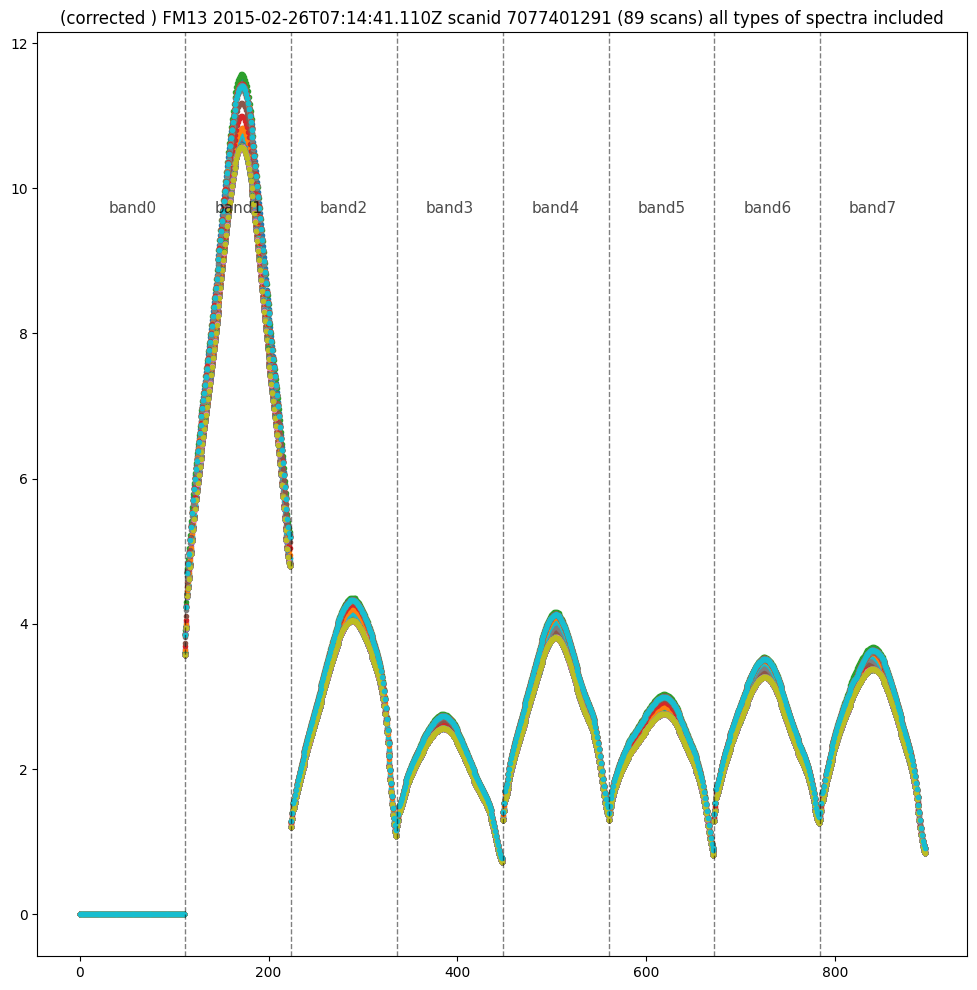

In [17]:
import numpy as np

new_data = np.stack(df_ac["specs"].to_numpy()).reshape(-1, 896)
# data= np.stack(new_specs).reshape(-1, 896)
fig, ax = plt.subplots(figsize=(12, 12))

ax.plot(new_data.T, ls="none", marker=".")
# ax.set_yscale("log")
ax.set_title(
    "(corrected ) FM13 2015-02-26T07:14:41.110Z scanid 7077401291 (89 scans) all types of spectra included"
)
band_width = 112
n_bands = 8
n_points = new_data.shape[1]

# y-position for text (top of plot, but inside axes)
y_text = ax.get_ylim()[1] * 0.8

for i in range(n_bands):
    x0 = i * band_width

    # vertical separator (skip x=0)
    if i > 0:
        ax.axvline(
            x=x0,
            color="k",
            linestyle="--",
            linewidth=1,
            alpha=0.5,
        )

    # band label in the center of the band
    ax.text(
        x0 + band_width / 2,
        y_text,
        f"band{i}",
        ha="center",
        va="center",
        fontsize=11,
        alpha=0.7,
    )
plt.show()

## frequency calibration

In [19]:
from odincal.frequency_calibration import get_sideband

sidebands = [
    get_sideband(frontend, lo, ssb)
    for frontend, lo, ssb in zip(
        df_ac.frontend, df_shk1["LO frequency 555"], df_shk1["SSB mechanism A 555"]
    )
]
df_ac[["if_freq", "sbpath"]] = sidebands
df_ac["sbpath"] /= 1e6  # MHz
df_ac["lo_freq"] = df_shk1["LO frequency 555"]
df_ac[["if_freq", "sbpath"]]

,if_freq,sbpath
stw,,
7077401291,3.900000e+09,0.000055
7077401323,3.900000e+09,0.000055
7077401355,3.900000e+09,0.000055
7077401387,3.900000e+09,0.000055
7077401419,3.900000e+09,0.000055
...,...,...
7077404010,3.900000e+09,0.000055
7077404042,3.900000e+09,0.000055
7077404074,3.900000e+09,0.000055


In [20]:
df_shk1

,varactor 495,varactor 549,varactor 572,varactor 555,gunn 495,gunn 549,gunn 572,gunn 555,harmonic mixer 495,harmonic mixer 549,...,119GHz voltage,119GHz current,119GHz DRO,ACS availability,ACDC1 sync,ACDC2 sync,LO frequency 495,LO frequency 549,LO frequency 572,LO frequency 555
stw,,,,,,,,,,,,,,,,,,,,,
7077401291,5.723078,5.008059,4.697435,5.541391,14.456655,1.953602,194.969482,206.007324,2.562588,2.5745,...,0.013676,-0.670288,26.582458,2512.0,58935,0,4.895880e+11,5.470680e+11,5.727660e+11,5.533020e+11
7077401323,5.723078,5.008059,4.697435,5.541391,14.456655,1.953602,194.969482,206.007324,2.562588,2.5745,...,0.013676,-0.670288,26.582458,2512.0,58935,0,4.895880e+11,5.470680e+11,5.727660e+11,5.533020e+11
7077401355,5.723078,5.008059,4.697435,5.541391,14.456655,1.953602,194.969482,206.007324,2.562588,2.5745,...,0.013676,-0.670288,26.582458,2512.0,58935,0,4.895880e+11,5.470680e+11,5.727660e+11,5.533020e+11
7077401387,5.723078,5.008059,4.697435,5.541391,14.456655,1.953602,194.969482,206.007324,2.562588,2.5745,...,0.013676,-0.670288,26.582458,2512.0,58935,0,4.895880e+11,5.470680e+11,5.727660e+11,5.533020e+11
7077401419,5.723078,5.008059,4.697435,5.541391,14.456655,1.953602,194.969482,206.007324,2.562588,2.5745,...,0.013676,-0.670288,26.582458,2512.0,58935,0,4.895880e+11,5.470680e+11,5.727660e+11,5.533020e+11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7077404010,5.723078,5.008059,4.697435,5.541391,14.456655,1.953602,194.871796,206.007324,2.561099,2.5745,...,0.041027,-0.670288,26.582458,2512.0,59727,0,4.895880e+11,5.470680e+11,5.727660e+11,5.533020e+11
7077404042,5.723078,5.008059,4.697435,5.541391,14.456655,1.953602,194.871796,206.007324,2.561099,2.5745,...,0.041027,-0.670288,26.582458,2512.0,59991,0,4.895880e+11,5.470680e+11,5.727660e+11,5.533020e+11
7077404074,5.723078,5.008059,4.697435,5.541391,14.456655,1.953602,194.871796,206.007324,2.561099,2.5745,...,0.041027,-0.670288,26.582458,2512.0,59991,0,4.895880e+11,5.470680e+11,5.727660e+11,5.533020e+11


In [21]:
def adjust_if_and_lofreq(
    if_freq: float,
    intmode: int,
    backend: str,
    current: float,
    frontend: str,
    lofreq: float
) -> tuple[float, float]:
    """
    Adjust IF frequency based on ADC split mode and backend,
    and optionally zero the LO frequency based on current/frontend.

    Returns:
        (if_freq, lofreq)
    """
    adc_split = 0x0200
    adc_upper = 0x0400

    if intmode & adc_split:
        upper = bool(intmode & adc_upper)

        if backend == "AC1":
            if_freq *= (3.6 / 3.9) if upper else (4.2 / 3.9)

        elif backend == "AC2":
            if_freq *= (4.2 / 3.9) if upper else (3.6 / 3.9)

    # LO suppression condition
    if current < 0.19 and frontend != "572":
        lofreq = 0.0

    return if_freq, lofreq

In [ ]:
if_lofreq_adj = [
    adjust_if_and_lofreq(if_freq, mode, backend, curr, frontend, lofreq)
    for if_freq, mode, backend, curr, frontend, lofreq in zip(
        df_ac["if_freq"],
        df_ac["mode"],
        df_ac["backend"],
        df_shk1["mixer current 555"],
        df_ac.frontend,
        df_shk1["LO frequency 555"],
        strict=True,
    )
]

In [23]:
if_lofreq_adj

[(3900000000.0, 553302032384.0),
 (3900000000.0, 553302032384.0),
 (3900000000.0, 553302032384.0),
 (3900000000.0, 553302032384.0),
 (3900000000.0, 553302032384.0),
 (3900000000.0, 553302032384.0),
 (3900000000.0, 553302032384.0),
 (3900000000.0, 553302032384.0),
 (3900000000.0, 553302032384.0),
 (3900000000.0, 553302032384.0),
 (3900000000.0, 553302032384.0),
 (3900000000.0, 553302032384.0),
 (3900000000.0, 553302032384.0),
 (3900000000.0, 553302032384.0),
 (3900000000.0, 553302032384.0),
 (3900000000.0, 553302032384.0),
 (3900000000.0, 553302032384.0),
 (3900000000.0, 553302032384.0),
 (3900000000.0, 553302032384.0),
 (3900000000.0, 553302032384.0),
 (3900000000.0, 553302032384.0),
 (3900000000.0, 553302032384.0),
 (3900000000.0, 553302032384.0),
 (3900000000.0, 553302032384.0),
 (3900000000.0, 553302032384.0),
 (3900000000.0, 553302032384.0),
 (3900000000.0, 553302032384.0),
 (3900000000.0, 553302032384.0),
 (3900000000.0, 553302032384.0),
 (3900000000.0, 553302032384.0),
 (39000000

In [24]:
def fcalibrate(lo_freq, if_freq,frontend,vgeo,temp_pll):
    """Perform frequency calibration."""
    if lo_freq == 0.0:
        return
    if frontend == '495' or frontend == '549':
        drift = 1.0 + (29.23 - 0.138 * temp_pll) * 1.0e-6
    else:
        drift = 1.0 + (24.69 - 0.109 * temp_pll) * 1.0e-6
    lo_freq = lo_freq * drift
    skyfreq = lo_freq + if_freq
    maxsup = lo_freq - if_freq
    # apply Doppler correction
    restfreq = skyfreq / (1.0 - vgeo / 2.99792456e8)
    return lo_freq, skyfreq, maxsup, restfreq

In [25]:
df_ac.columns

Index(['u_mon', 'u_cc', 'mon', 'cc', 'bands', 'mode', 'inttime', 'ssb_fq',
       'ssb_att', 'backend', 'frontend', 'sig_type', 'specs', 'if_freq',
       'sbpath', 'lo_freq'],
      dtype='object')

In [26]:
fcal = [
    fcalibrate(lo_freq, if_freq, frontend, vgeo, temp_pll)
    for lo_freq, if_freq, frontend, vgeo, temp_pll in zip(
        df_ac["lo_freq"],
        df_ac["if_freq"],
        df_ac["frontend"],
        df_att1["vgeo"],
        df_shk1["image load A-side"]
    )
]

In [27]:
df_ac[['lo_freq', 'skyfreq', 'maxsup', 'restfreq']] = fcal
df_ac[['lo_freq', 'skyfreq', 'maxsup', 'restfreq']] /1e9

,lo_freq,skyfreq,maxsup,restfreq
stw,,,,
7077401291,553.313973,557.213973,549.413973,557.201330
7077401323,553.313973,557.213973,549.413973,557.201331
7077401355,553.313973,557.213973,549.413973,557.201332
7077401387,553.313973,557.213973,549.413973,557.201333
7077401419,553.313973,557.213973,549.413973,557.201334
...,...,...,...,...
7077404010,553.313972,557.213972,549.413972,557.201414
7077404042,553.313972,557.213972,549.413972,557.201416
7077404074,553.313972,557.213972,549.413972,557.201417
